# Аналіз даних доходів населення UCI Adult

**В завданні пропонується за допомогою Pandas дати відповідь на кілька запитань по даним репозиторія UCI [Adult](https://archive.ics.uci.edu/ml/datasets/Adult).**

Унікальні значення ознак:
- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous.
- capital-loss: continuous.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.   
- salary: >50K,<=50K

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('adult.data.csv', skipinitialspace=True)
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**1. Скільки чоловіків и жінок (ознака *sex*) представлено в цьому наборі даних?**

In [ ]:
data['sex'].value_counts()

,count
sex,
Male,21790
Female,10771


**2. Який середній вік (ознака *age*) жінок?**

In [ ]:
data.groupby('sex')['age'].mean().head(1)#.iloc[0]

,age
sex,
Female,36.85823


In [ ]:
data.loc[data['sex'] == 'Female', 'age'].mean()

np.float64(36.85823043357163)

**3. Яка частка громадян Німеччини (ознака *native-country*)?**

In [ ]:
#(data.groupby(data['native-country'] == 'Germany').size() / len(data)).sort_values(ascending=True).head(1)
(data['native-country'] == 'Germany').value_counts(normalize=True).sort_values(ascending=True).head(1)

,proportion
native-country,
True,0.004207


In [ ]:
(data['native-country'] == 'Germany').mean()


np.float64(0.004207487485028101)

**4-5. Які средні значення та средньоквадратичні відхилення віку тих, хто отримує більше 50K на рік (ознака *salary*) і тих, хто отримує менше 50K на рік?**

In [ ]:
#data.groupby('salary')['age'].mean()
data.loc[data['salary'] == '>50K', ['age']].agg(['mean', 'std'])

,age
mean,44.249841
std,10.519028


**6. Чи правда, що люди, які отримують більше 50k, мають як мінімум вищу освіту? (ознака *education – Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters* или *Doctorate*)**

In [ ]:
data[['education', 'education-num']].drop_duplicates().sort_values('education-num')

,education,education-num
224,Preschool,1
160,1st-4th,2
56,5th-6th,3
15,7th-8th,4
6,9th,5
77,10th,6
3,11th,7
415,12th,8
2,HS-grad,9
10,Some-college,10


In [ ]:
data.loc[(data['salary'] == '>50K')&(data['education-num'] < 11), ['education']].agg(Кількість_людей_із_ЗП_більше_50K_без_вищої_освіти=('education', 'count')) #Кількість людей із ЗП >50K без вищої освіти

,education
Кількість_людей_із_ЗП_більше_50K_без_вищої_освіти,3306


**7. Порахуйте статистику віку для кожної раси (ознака *race*) і кожної статі. Використайте *groupby* и *describe*. Знайдіть таким чином максимальний вік чоловіків раси *Amer-Indian-Eskimo*.**

In [ ]:
stat_race_sex = data.groupby(['race', 'sex'])['age'].describe()
stat_race_sex

count       mean        std   min   25%   50%  \
race               sex                                                       
Amer-Indian-Eskimo Female    119.0  37.117647  13.114991  17.0  27.0  36.0   
                   Male      192.0  37.208333  12.049563  17.0  28.0  35.0   
Asian-Pac-Islander Female    346.0  35.089595  12.300845  17.0  25.0  33.0   
                   Male      693.0  39.073593  12.883944  18.0  29.0  37.0   
Black              Female   1555.0  37.854019  12.637197  17.0  28.0  37.0   
                   Male     1569.0  37.682600  12.882612  17.0  27.0  36.0   
Other              Female    109.0  31.678899  11.631599  17.0  23.0  29.0   
                   Male      162.0  34.654321  11.355531  17.0  26.0  32.0   
White              Female   8642.0  36.811618  14.329093  17.0  25.0  35.0   
                   Male    19174.0  39.652498  13.436029  17.0  29.0  38.0   

                             75%   max  
race               sex                  
Amer-Indian-Eskimo Female  46.00  80.0  
                   Male    45.00  82.0  
Asian-Pac-Islander Female  43.75  75.0  
                   Male    46.00  90.0  
Black              Female  46.00  90.0  
                   Male    46.00  90.0  
Other              Female  39.00  74.0  
                   Male    42.00  77.0  
White              Female  46.00  90.0  
                   Male    49.00  90.0

In [ ]:
group_index = ('Amer-Indian-Eskimo', 'Male')
stat_race_sex.loc[group_index, ['max']].rename({'max':'max_age'})

,Amer-Indian-Eskimo
,Male
max_age,82.0


**8. Серед кого більша доля багатіших (>50K): серед одружених чи не одружених чоловіків (ознака *marital-status*)? За одружених вважаємо тих, у кого *marital-status* починається із *Married* (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), всі інші - не одружені.**

In [ ]:
married_male = (data['marital-status'].str.startswith('Married')) & (data['sex'] == 'Male')
stat_married_male = (data[married_male]['salary'] == '>50K').mean()
print(stat_married_male)
(data[married_male]['salary'].value_counts(normalize=True).rename('Married_male, %')*100).map('{:.2f}'.format)#.sort_values(ascending=True).head(1)

0.4405139945351156


,"Married_male, %"
salary,
<=50K,55.95
>50K,44.05


**9. Яку максимальну кількість годин в тиждень працює людина (ознака *hours-per-week*)? Скільки людей працюють таку кількість годин і який відсоток серед них багатих?**

In [ ]:
working_hours_max = data['hours-per-week'].max()
workers_max = data[data['hours-per-week'] == working_hours_max]
percentage_reach = ((workers_max['salary'] == '>50K').mean()*100)
pd.DataFrame([{'working_hours_max':working_hours_max,
              'workers_max':len(workers_max),
              'percentage_reach':percentage_reach
             }])

,working_hours_max,workers_max,percentage_reach
0,99,85,29.411765


**10. Порахуйте середню тривалість роботи на тиждень (*hours-per-week*) серед багатих і бідних (*salary*) для кожної країни (*native-country*).**

In [ ]:
rich_workers_avg = data[data['salary'] == '>50K'].groupby('native-country')['hours-per-week'].mean()
rich_workers = data[data['salary'] == '>50K'].groupby('native-country')['hours-per-week'].count()
poor_workers_avg = data[data['salary'] == '>50K'].groupby('native-country')['hours-per-week'].mean()
poor_workers = data[data['salary'] == '>50K'].groupby('native-country')['hours-per-week'].count()
pd.DataFrame({'rich_workers_avg':rich_workers_avg,
              'rich_workers':rich_workers,
              'poor_workers_avg':poor_workers_avg,
              'poor_workers':poor_workers,
             })

,rich_workers_avg,rich_workers,poor_workers_avg,poor_workers
native-country,,,,
?,45.547945,146,45.547945,146
Cambodia,40.000000,7,40.000000,7
Canada,45.641026,39,45.641026,39
China,38.900000,20,38.900000,20
Columbia,50.000000,2,50.000000,2
Cuba,42.440000,25,42.440000,25
Dominican-Republic,47.000000,2,47.000000,2
Ecuador,48.750000,4,48.750000,4
El-Salvador,45.000000,9,45.000000,9


**11. (Бонус) Покажіть через візуалізацію:**
* Чи залежить кількість годин роботи від віку респондента?
* Чи однаковий розподіл marital-status у різних статей?
* Як кількість годин роботи змінюється для різних occupation?


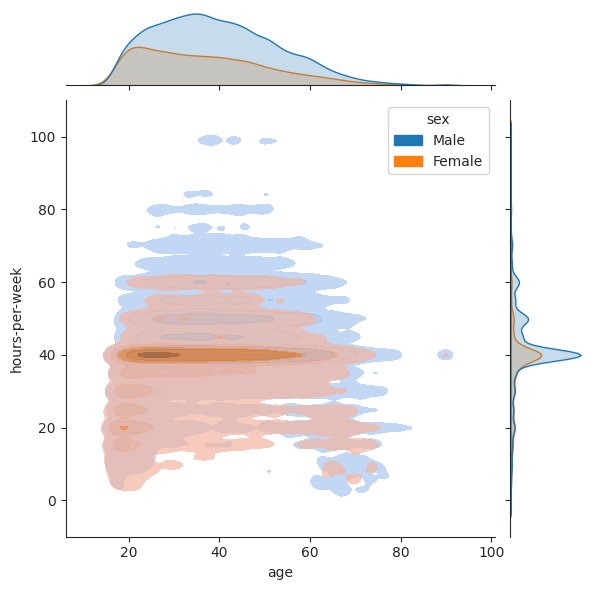

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('ticks')
sns.jointplot(
    kind='kde',
    data=data,
    x='age',
    y='hours-per-week',
    hue='sex',
    fill=True,
    thresh=0.05,
    levels=5,
    alpha=.7,
    bw_adjust=0.5)
plt.show()



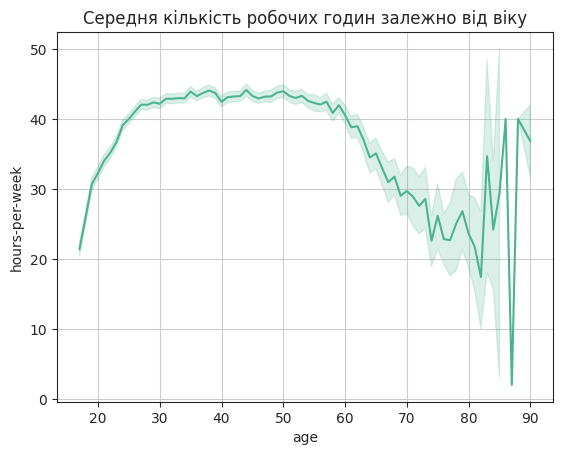

In [ ]:
sns.lineplot(data=data, x='age', y='hours-per-week', color='#4CB391')
plt.title('Середня кількість робочих годин залежно від віку')
plt.grid(True)

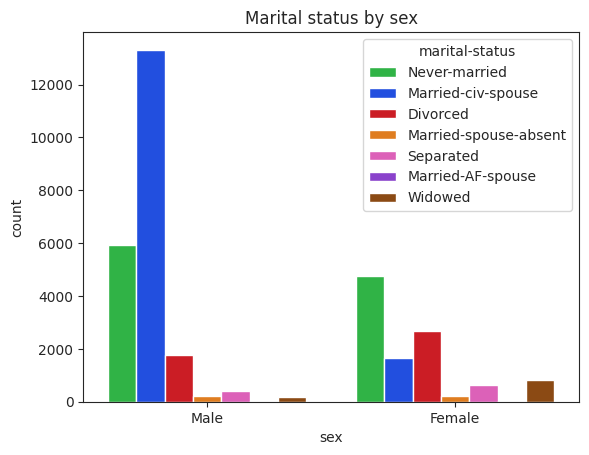

In [ ]:
import random
palette = sns.color_palette('bright', 7)
random.shuffle(palette)
sns.countplot(data=data, x="sex", hue='marital-status', palette=palette)
plt.title('Marital status by sex')
plt.show()

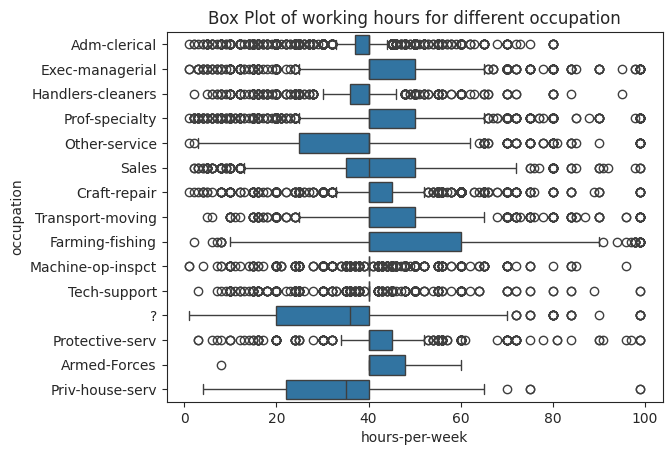

In [ ]:
sns.boxplot(data=data, x='hours-per-week', y='occupation')
plt.title('Box Plot of working hours for different occupation')
plt.show()